# Multi-Dataset Training for Generalization — DDAMFN on RAF-DB + FER2013

Trained on RAF-DB alone, the model scores 91% on RAF-DB but only **55% on FER2013**. FER2013 faces are 48×48
grayscale, a very different *domain* from RAF-DB's colour images. This notebook fine-tunes the RAF-DB model on
**both datasets together** to close that gap:

* **Starts from the trained RAF-DB checkpoint**, so this is a fine-tune, not training from scratch.
* **Domain-balanced sampling**: each batch is about half RAF-DB and half FER2013.
* **Domain-bridging augmentation**: random grayscale and low-resolution simulation applied to all images.
* Same recipe as the original model: **SAM** optimizer + attention-diversity loss, plus label smoothing for FER2013's noisy labels.
* **Model selection on validation splits only.** Test sets are evaluated once at the end.
* **CK+ is never used for training.** It stays a truly unseen dataset that measures *real* generalization.

## 0 · Model code

In [ ]:
%%writefile MixedFeatureNet.py

from torch.nn import Linear, Conv2d, BatchNorm1d, BatchNorm2d, PReLU, Sequential, Module
import torch
import torch.nn as nn
class Flatten(Module):
    def forward(self, input):
        return input.view(input.size(0), -1)

def l2_norm(input,axis=1):
    norm = torch.norm(input,2,axis,True)
    output = torch.div(input, norm)
    return output

class Conv_block(Module):
    def __init__(self, in_c, out_c, kernel=(1, 1), stride=(1, 1), padding=(0, 0), groups=1):
        super(Conv_block, self).__init__()
        self.conv = Conv2d(in_c, out_channels=out_c, kernel_size=kernel, groups=groups, stride=stride, padding=padding, bias=False)
        self.bn = BatchNorm2d(out_c)
        self.prelu = PReLU(out_c)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.prelu(x)
        return x

class Linear_block(Module):
    def __init__(self, in_c, out_c, kernel=(1, 1), stride=(1, 1), padding=(0, 0), groups=1):
        super(Linear_block, self).__init__()
        self.conv = Conv2d(in_c, out_channels=out_c, kernel_size=kernel, groups=groups, stride=stride, padding=padding, bias=False)
        self.bn = BatchNorm2d(out_c)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return x

class Depth_Wise(Module):
     def __init__(self, in_c, out_c, residual = False, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=1):
        super(Depth_Wise, self).__init__()
        self.conv = Conv_block(in_c, out_c=groups, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.conv_dw = Conv_block(groups, groups, groups=groups, kernel=kernel, padding=padding, stride=stride)
        self.project = Linear_block(groups, out_c, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.residual = residual
     def forward(self, x):
        if self.residual:
            short_cut = x
        x = self.conv(x)
        x = self.conv_dw(x)
        x = self.project(x)
        if self.residual:
            output = short_cut + x
        else:
            output = x
        return output
  

class Swish(nn.Module):
    def __init__(self):
        super(Swish, self).__init__()

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return x * self.sigmoid(x)

NON_LINEARITY = {
    'ReLU': nn.ReLU(inplace=True),
    'Swish': Swish(),
}        


class h_sigmoid(nn.Module):
    def __init__(self, inplace=True):
        super(h_sigmoid, self).__init__()
        self.relu = nn.ReLU6(inplace=inplace)

    def forward(self, x):
        return self.relu(x + 3) / 6

class h_swish(nn.Module):
    def __init__(self, inplace=True):
        super(h_swish, self).__init__()
        self.sigmoid = h_sigmoid(inplace=inplace)

    def forward(self, x):
        return x * self.sigmoid(x)

class swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)
    
class CoordAtt(nn.Module):
    def __init__(self, inp, oup, groups=32):
        super(CoordAtt, self).__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))

        mip = max(8, inp // groups)

        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.conv2 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv3 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.relu = h_swish()

    def forward(self, x):
        identity = x
        n,c,h,w = x.size()
        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)

        y = torch.cat([x_h, x_w], dim=2)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.relu(y) 
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)

        x_h = self.conv2(x_h).sigmoid()
        x_w = self.conv3(x_w).sigmoid()
        x_h = x_h.expand(-1, -1, h, w)
        x_w = x_w.expand(-1, -1, h, w)

        y = identity * x_w * x_h

        return y

        
class MDConv(Module):
    def __init__(self, channels, kernel_size, split_out_channels, stride):
        super(MDConv, self).__init__()
        self.num_groups = len(kernel_size)
        self.split_channels = split_out_channels
        self.mixed_depthwise_conv = nn.ModuleList()
        for i in range(self.num_groups):
            self.mixed_depthwise_conv.append(Conv2d(
                self.split_channels[i],
                self.split_channels[i],
                kernel_size[i],
                stride=stride,
                padding=kernel_size[i]//2,
                groups=self.split_channels[i],
                bias=False
            ))
        self.bn = BatchNorm2d(channels)
        self.prelu = PReLU(channels)            
       
    def forward(self, x):
        if self.num_groups == 1:
            return self.mixed_depthwise_conv[0](x)

        x_split = torch.split(x, self.split_channels, dim=1)
        x = [conv(t) for conv, t in zip(self.mixed_depthwise_conv, x_split)]
        x = torch.cat(x, dim=1)

        return x        
      
        
class Mix_Depth_Wise(Module):
     def __init__(self, in_c, out_c, residual = False, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=1, kernel_size=[3,5,7], split_out_channels=[64,32,32]):
        super(Mix_Depth_Wise, self).__init__()
        self.conv = Conv_block(in_c, out_c=groups, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.conv_dw = MDConv(channels=groups, kernel_size=kernel_size, split_out_channels=split_out_channels, stride=stride)
        self.CA = CoordAtt(groups, groups)
        self.project = Linear_block(groups, out_c, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.residual = residual
     def forward(self, x):
        if self.residual:
            short_cut = x
        x = self.conv(x)
        x = self.conv_dw(x)
        x = self.CA(x)
        x = self.project(x)
        if self.residual:
            output = short_cut + x
        else:
            output = x
        return output
          
class Residual(Module):
    def __init__(self, c, num_block, groups, kernel=(3, 3), stride=(1, 1), padding=(1, 1)):
        super(Residual, self).__init__()
        modules = []
        for _ in range(num_block):
            modules.append(Depth_Wise(c, c, residual=True, kernel=kernel, padding=padding, stride=stride, groups=groups))
        self.model = Sequential(*modules)
    def forward(self, x):
        return self.model(x)
        
class Mix_Residual(Module):
    def __init__(self, c, num_block, groups, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5], split_out_channels=[64,64]):
        super(Mix_Residual, self).__init__()
        modules = []
        for _ in range(num_block):
            modules.append(Mix_Depth_Wise(c, c, residual=True, kernel=kernel, padding=padding, stride=stride, groups=groups, kernel_size=kernel_size, split_out_channels=split_out_channels ))
        self.model = Sequential(*modules)
    def forward(self, x):
        return self.model(x)
        

class MixedFeatureNet(Module):
    def __init__(self, embedding_size=256, out_h=7, out_w=7):
        super(MixedFeatureNet, self).__init__()
        #112x112
        self.conv1 = Conv_block(3, 64, kernel=(3, 3), stride=(2, 2), padding=(1, 1))
        #56x56
        self.conv2_dw = Conv_block(64, 64, kernel=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
        self.conv_23 = Mix_Depth_Wise(64, 64, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=128, kernel_size=[3,5,7], split_out_channels=[64,32,32] )
        
        #28x28
        self.conv_3 = Mix_Residual(64, num_block=9, groups=128, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5], split_out_channels=[96,32])
        self.conv_34 = Mix_Depth_Wise(64, 128, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=256, kernel_size=[3,5,7],split_out_channels=[128,64,64] )
        
        #14x14
        self.conv_4 = Mix_Residual(128, num_block=16, groups=256, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5], split_out_channels=[192,64])
        self.conv_45 = Mix_Depth_Wise(128, 256, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=512*2, kernel_size=[3,5,7,9],split_out_channels=[128*2,128*2,128*2,128*2] )
        #7x7
        self.conv_5 = Mix_Residual(256, num_block=6, groups=512, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5,7], split_out_channels=[86*2,85*2,85*2])                
        self.conv_6_sep = Conv_block(256, 512, kernel=(1, 1), stride=(1, 1), padding=(0, 0))
        self.conv_6_dw = Linear_block(512, 512, groups=512, kernel=(out_h, out_w), stride=(1, 1), padding=(0, 0))
        self.conv_6_flatten = Flatten()
        self.linear = Linear(512, embedding_size, bias=False)
        self.bn = BatchNorm1d(embedding_size)
    
    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2_dw(out)
        out = self.conv_23(out)
        out = self.conv_3(out)
        out = self.conv_34(out)
        out = self.conv_4(out)
        out = self.conv_45(out)
        out = self.conv_5(out)
        out = self.conv_6_sep(out)
        out = self.conv_6_dw(out)
        out = self.conv_6_flatten(out)
        out = self.linear(out)
        out = self.bn(out)

        return l2_norm(out)

Writing MixedFeatureNet.py


In [ ]:
%%writefile DDAM.py
from torch import nn
import torch
import MixedFeatureNet
from torch.nn import Module
import os
class Linear_block(Module):
    def __init__(self, in_c, out_c, kernel=(1, 1), stride=(1, 1), padding=(0, 0), groups=1):
        super(Linear_block, self).__init__()
        self.conv = nn.Conv2d(in_c, out_channels=out_c, kernel_size=kernel, groups=groups, stride=stride, padding=padding, bias=False)
        self.bn = nn.BatchNorm2d(out_c)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return x

class Flatten(Module):
    def forward(self, input):
        return input.view(input.size(0), -1)
        
class DDAMNet(nn.Module):
    def __init__(self, num_class=7,num_head=2, pretrained=True):
        super(DDAMNet, self).__init__()

        net = MixedFeatureNet.MixedFeatureNet()
                
        if pretrained:
            net = torch.load(os.path.join('./pretrained/', "MFN_msceleb.pth"))       
      
        self.features = nn.Sequential(*list(net.children())[:-4])
        self.num_head = num_head
        for i in range(int(num_head)):
            setattr(self,"cat_head%d" %(i), CoordAttHead())                  
      
        self.Linear = Linear_block(512, 512, groups=512, kernel=(7, 7), stride=(1, 1), padding=(0, 0))
        self.flatten = Flatten()      
        self.fc = nn.Linear(512, num_class)
        self.bn = nn.BatchNorm1d(num_class)
        
    def forward(self, x):
        x = self.features(x)
        heads = []
       
        for i in range(self.num_head):
            heads.append(getattr(self,"cat_head%d" %i)(x))
        head_out =heads
        
        y = heads[0]
        
        for i in range(1,self.num_head):
            y = torch.max(y,heads[i])                     
        
        y = x*y
        y = self.Linear(y)
        y = self.flatten(y) 
        out = self.fc(y)        
        return out, x, head_out
        
class h_sigmoid(nn.Module):
    def __init__(self, inplace=True):
        super(h_sigmoid, self).__init__()
        self.relu = nn.ReLU6(inplace=inplace)
    def forward(self, x):
        return self.relu(x + 3) / 6
                      
class h_swish(nn.Module):
    def __init__(self, inplace=True):
        super(h_swish, self).__init__()
        self.sigmoid = h_sigmoid(inplace=inplace)
    def forward(self, x):
        return x * self.sigmoid(x)

class CoordAttHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.CoordAtt = CoordAtt(512,512)
    def forward(self, x):
        ca = self.CoordAtt(x)
        return ca  
        
class CoordAtt(nn.Module):
    def __init__(self, inp, oup, groups=32):
        super(CoordAtt, self).__init__()
      
        self.Linear_h = Linear_block(inp, inp, groups=inp, kernel=(1, 7), stride=(1, 1), padding=(0, 0))        
        self.Linear_w = Linear_block(inp, inp, groups=inp, kernel=(7, 1), stride=(1, 1), padding=(0, 0))
        
        mip = max(8, inp // groups)

        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.conv2 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv3 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.relu = h_swish()
        self.Linear = Linear_block(oup, oup, groups=oup, kernel=(7, 7), stride=(1, 1), padding=(0, 0))
        self.flatten = Flatten() 

    def forward(self, x):
        identity = x
        n,c,h,w = x.size()
        x_h = self.Linear_h(x)
        x_w = self.Linear_w(x)
        x_w = x_w.permute(0, 1, 3, 2)

        y = torch.cat([x_h, x_w], dim=2)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.relu(y) 
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)

        x_h = self.conv2(x_h).sigmoid()
        x_w = self.conv3(x_w).sigmoid()
        x_h = x_h.expand(-1, -1, h, w)
        x_w = x_w.expand(-1, -1, h, w)
        
        y = x_w * x_h
 
        return y

Writing DDAM.py


## 1 · Data — RAF-DB, FER2013 (train/test) and CK+ (held out)

In [ ]:
import os, sys, json, time, copy, random, numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
sys.path.insert(0, os.getcwd())
from DDAM import DDAMNet

SEED = 42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DATA = os.environ.get('DATA_ROOT', '/kaggle/input')
OUT  = os.environ.get('OUT_ROOT', '/kaggle/working')
FIG  = os.path.join(OUT, 'figs'); os.makedirs(FIG, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CFG = dict(epochs=int(os.environ.get('EPOCHS', 12)), lr=1e-4, rho=0.05, batch=128,
           workers=int(os.environ.get('WORKERS', 4)), label_smoothing=0.1)
S = 112
CLASS_NAMES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
FOLDER2EMO = {'angry': 'Anger', 'anger': 'Anger', 'disgust': 'Disgust', 'fear': 'Fear', 'happy': 'Happiness',
              'happiness': 'Happiness', 'neutral': 'Neutral', 'sad': 'Sadness', 'sadness': 'Sadness',
              'surprise': 'Surprise'}
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titleweight': 'bold'})
def save(fig, name):
    fig.savefig(os.path.join(FIG, name), bbox_inches='tight', facecolor='white'); plt.show()

train_csv = test_csv = ckpt_path = None; IMG = {}; FER_TR, FER_TE, CK = [], [], []
for root, _, files in os.walk(DATA):
    low = root.lower().replace('\\', '/'); parent = os.path.basename(root).lower()
    for f in files:
        p = os.path.join(root, f)
        if   f == 'train_labels.csv': train_csv = p
        elif f == 'test_labels.csv':  test_csv = p
        elif f in ('ddamfn_rafdb_final.pth', 'ddamfn_rafdb_best.pth'): ckpt_path = p
        elif f.lower().endswith(('.jpg', '.jpeg', '.png')):
            emo = FOLDER2EMO.get(parent)
            if emo and 'fer' in low and '/test' in low:    FER_TE.append((p, CLASS_NAMES.index(emo)))
            elif emo and 'fer' in low and '/train' in low: FER_TR.append((p, CLASS_NAMES.index(emo)))
            elif emo and 'ck' in low:                      CK.append((p, CLASS_NAMES.index(emo)))
            else:                                          IMG[f] = p

def dedup(items):  # some datasets ship the same images in two folders -> one copy per (label, file)
    seen, out = set(), []
    for p, y in items:
        k = (y, os.path.basename(p))
        if k not in seen: seen.add(k); out.append((p, y))
    return out
FER_TR, FER_TE, CK = dedup(FER_TR), dedup(FER_TE), dedup(CK)
assert train_csv and test_csv and ckpt_path and FER_TR and FER_TE, 'need RAF-DB, the checkpoint and FER2013 as inputs'

raf_full = pd.read_csv(train_csv); raf_test_df = pd.read_csv(test_csv)
raf_tr_df, raf_va_df = train_test_split(raf_full, test_size=0.10, stratify=raf_full['label'], random_state=SEED)  # same split as the original model
to_items = lambda df: [(IMG[n], int(l) - 1) for n, l in zip(df['image'], df['label'])]
RAF_TR, RAF_VA, RAF_TE = to_items(raf_tr_df), to_items(raf_va_df), to_items(raf_test_df)
FER_TR, FER_VA = train_test_split(FER_TR, test_size=0.10, stratify=[y for _, y in FER_TR], random_state=SEED)

if os.environ.get('FAST'):  # local smoke test only
    RAF_TR, FER_TR = RAF_TR[:256], FER_TR[:256]
print(f'RAF-DB  train {len(RAF_TR)} | val {len(RAF_VA)} | test {len(RAF_TE)}')
print(f'FER2013 train {len(FER_TR)} | val {len(FER_VA)} | test {len(FER_TE)}')
print(f'CK+ (held out, never trained on) {len(CK)} | device {DEVICE} | epochs {CFG["epochs"]}')

RAF-DB  train 11043 | val 1228 | test 3068
FER2013 train 25838 | val 2871 | test 7178
CK+ (held out, never trained on) 927 | device cuda | epochs 12


## 2 · Augmentation, sampler, model, SAM

In [ ]:
class LowRes:
    """Simulate low-resolution sources (FER2013's 48 px faces, cheap webcams): downscale then upscale."""
    def __init__(self, p=0.2, lo=28, hi=64): self.p, self.lo, self.hi = p, lo, hi
    def __call__(self, img):
        if random.random() < self.p:
            s = random.randint(self.lo, self.hi)
            img = img.resize((s, s), Image.BILINEAR).resize((S, S), Image.BILINEAR)
        return img

NORM = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_tf = transforms.Compose([
    transforms.Resize((S, S)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.RandomRotation(10), transforms.RandomCrop(S, padding=8)], p=0.5),
    transforms.RandomGrayscale(p=0.2),            # bridges colour RAF-DB <-> grayscale FER2013
    LowRes(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(), NORM,
    transforms.RandomErasing(scale=(0.02, 0.25)),
])
eval_tf = transforms.Compose([transforms.Resize((S, S)), transforms.ToTensor(), NORM])

class Faces(Dataset):
    def __init__(self, items, tf): self.items, self.tf = items, tf
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, y = self.items[i]
        return self.tf(Image.open(p).convert('RGB')), y

train_items = RAF_TR + FER_TR
# domain-balanced: half the samples from each dataset; one "epoch" = 2 x |RAF train|
w = [0.5 / len(RAF_TR)] * len(RAF_TR) + [0.5 / len(FER_TR)] * len(FER_TR)
sampler = WeightedRandomSampler(w, num_samples=2 * len(RAF_TR), replacement=True)
train_loader = DataLoader(Faces(train_items, train_tf), batch_size=CFG['batch'], sampler=sampler,
                          num_workers=CFG['workers'], pin_memory=True, drop_last=True)
def eval_loader(items): return DataLoader(Faces(items, eval_tf), batch_size=256, num_workers=CFG['workers'])

class AttentionLoss(nn.Module):          # same as the original DDAMFN training
    def forward(self, heads):
        n = len(heads); loss = 0.0; cnt = 0
        if n > 1:
            for i in range(n - 1):
                for j in range(i + 1, n):
                    loss = loss + F.mse_loss(heads[i], heads[j]); cnt += 1
            loss = cnt / (loss + 1e-7)
        return loss

class SAM(torch.optim.Optimizer):        # Sharpness-Aware Minimization (Foret et al., 2021)
    def __init__(self, params, base_optimizer, rho=0.05, **kw):
        super().__init__(params, dict(rho=rho, **kw))
        self.base_optimizer = base_optimizer(self.param_groups, **kw)
        self.param_groups = self.base_optimizer.param_groups
    @torch.no_grad()
    def first_step(self):
        norm = torch.norm(torch.stack([p.grad.norm(2) for g in self.param_groups for p in g['params'] if p.grad is not None]), 2)
        for g in self.param_groups:
            scale = g['rho'] / (norm + 1e-12)
            for p in g['params']:
                if p.grad is None: continue
                self.state[p]['old_p'] = p.data.clone(); p.add_(p.grad * scale)
        self.zero_grad()
    @torch.no_grad()
    def second_step(self):
        for g in self.param_groups:
            for p in g['params']:
                if p.grad is not None: p.data = self.state[p]['old_p']
        self.base_optimizer.step(); self.zero_grad()

def load_model():
    m = DDAMNet(num_class=7, num_head=2, pretrained=False).to(DEVICE)
    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    m.load_state_dict(ck.get('model_state_dict', ck)); return m

@torch.no_grad()
def predict(m, items):
    m.eval(); out = []
    for x, _ in eval_loader(items): out.append(m(x.to(DEVICE))[0].float().cpu())
    return torch.cat(out).numpy()

def scores(logits, items):
    y = np.array([l for _, l in items]); p = logits.argmax(1)
    return 100 * (p == y).mean(), 100 * balanced_accuracy_score(y, p)

baseline = load_model()
EVALS = {'RAF-DB test': RAF_TE, 'FER2013 test': FER_TE, 'CK+ (unseen)': CK}
before = {k: scores(predict(baseline, v), v) for k, v in EVALS.items() if v}
for k, (a, b) in before.items(): print(f'BEFORE  {k:14s} overall {a:6.2f}% | mean-class {b:6.2f}%')
del baseline

BEFORE  RAF-DB test    overall  91.07% | mean-class  84.64%
BEFORE  FER2013 test   overall  55.29% | mean-class  50.89%
BEFORE  CK+ (unseen)   overall  77.02% | mean-class  69.16%


## 3 · Fine-tune on RAF-DB + FER2013

epoch  1/12 | loss 1.353 | val RAF 87.70% | val FER 64.30% | 296s  * best
epoch  2/12 | loss 1.178 | val RAF 88.11% | val FER 64.96% | 300s  * best
epoch  3/12 | loss 1.125 | val RAF 88.11% | val FER 66.74% | 298s  * best
epoch  4/12 | loss 1.094 | val RAF 88.27% | val FER 67.19% | 298s  * best
epoch  5/12 | loss 1.057 | val RAF 89.25% | val FER 68.16% | 298s  * best
epoch  6/12 | loss 1.026 | val RAF 89.41% | val FER 68.51% | 299s  * best
epoch  7/12 | loss 1.013 | val RAF 89.41% | val FER 69.73% | 299s  * best
epoch  8/12 | loss 0.995 | val RAF 89.25% | val FER 70.46% | 298s  * best
epoch  9/12 | loss 0.985 | val RAF 89.09% | val FER 69.66% | 298s
epoch 10/12 | loss 0.982 | val RAF 89.66% | val FER 70.15% | 298s  * best
epoch 11/12 | loss 0.984 | val RAF 89.50% | val FER 70.71% | 299s  * best
epoch 12/12 | loss 0.975 | val RAF 89.41% | val FER 70.46% | 297s


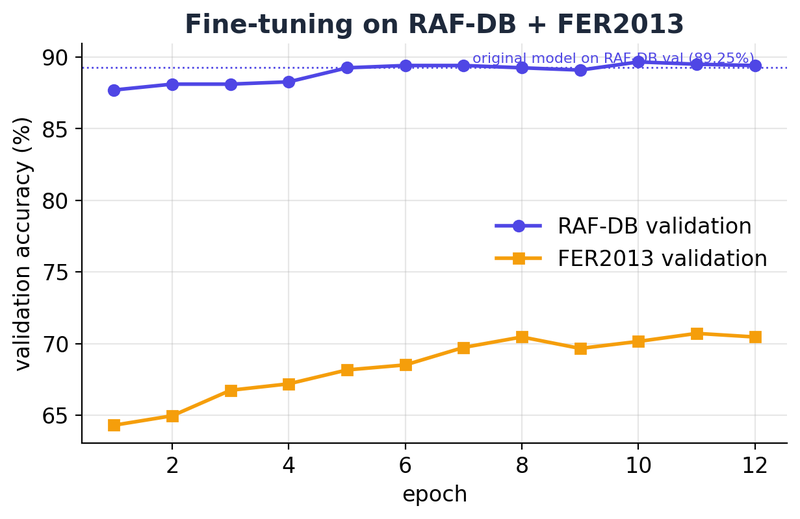

In [ ]:
model = load_model()
criterion_cls = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])
criterion_at = AttentionLoss()
optimizer = SAM(model.parameters(), torch.optim.Adam, rho=CFG['rho'], lr=CFG['lr'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer.base_optimizer, T_max=CFG['epochs'])

def step_loss(imgs, labels):
    out, _, heads = model(imgs)
    return criterion_cls(out, labels) + 0.1 * criterion_at(heads)

history, best, best_state = [], -1, None
for ep in range(1, CFG['epochs'] + 1):
    model.train(); t0 = time.time(); running = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        loss = step_loss(imgs, labels); loss.backward(); optimizer.first_step()
        step_loss(imgs, labels).backward(); optimizer.second_step()
        running += loss.item()
    scheduler.step()
    raf_va, _ = scores(predict(model, RAF_VA), RAF_VA); fer_va, _ = scores(predict(model, FER_VA), FER_VA)
    score = (raf_va + fer_va) / 2
    history.append((ep, running / len(train_loader), raf_va, fer_va))
    flag = ''
    if score > best: best, best_state, flag = score, copy.deepcopy(model.state_dict()), '  * best'
    print(f'epoch {ep:2d}/{CFG["epochs"]} | loss {running / len(train_loader):.3f} | val RAF {raf_va:.2f}% | val FER {fer_va:.2f}% | {time.time() - t0:.0f}s{flag}')

model.load_state_dict(best_state)
torch.save({'model_state_dict': best_state, 'class_names': CLASS_NAMES, 'trained_on': 'RAF-DB + FER2013 (fine-tuned from RAF-DB DDAMFN)'},
           os.path.join(OUT, 'ddamfn_raf_fer_generalist.pth'))
h = np.array(history)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(h[:, 0], h[:, 2], 'o-', label='RAF-DB val'); ax.plot(h[:, 0], h[:, 3], 's-', label='FER2013 val')
ax.set_xlabel('epoch'); ax.set_ylabel('validation accuracy (%)'); ax.grid(alpha=.3); ax.legend(frameon=False)
ax.set_title('Fine-tuning on RAF-DB + FER2013'); save(fig, 'multidataset_training.png')

## 4 · Final evaluation — once, on all test sets (CK+ never seen in training)

                         RAF-DB only        RAF-DB + FER2013
RAF-DB test       91.07% / 84.64%   ->    90.81% / 84.45%   (-0.26 pts overall)
FER2013 test      55.29% / 50.89%   ->    69.00% / 64.77%   (+13.71 pts overall)
CK+ (unseen)      77.02% / 69.16%   ->    78.96% / 73.40%   (+1.94 pts overall)


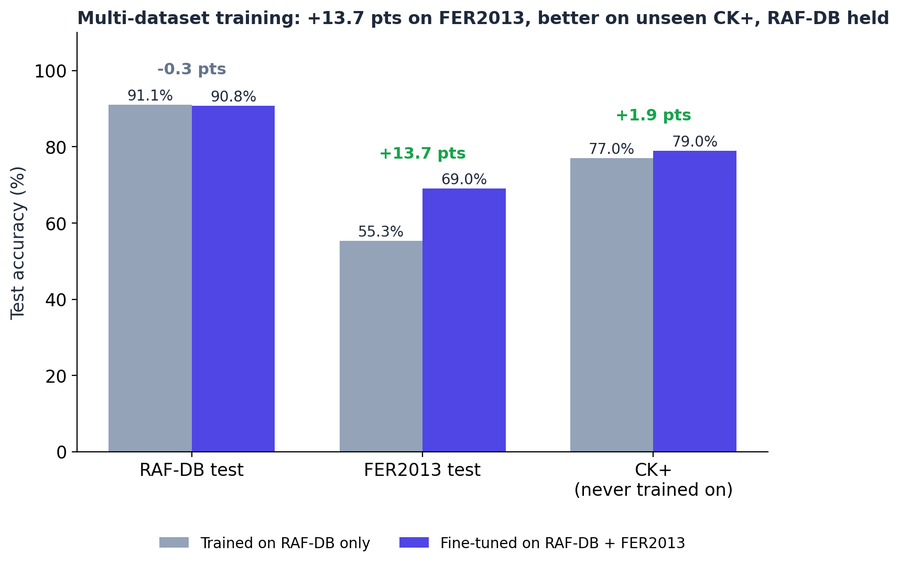

In [ ]:
after = {k: scores(predict(model, v), v) for k, v in EVALS.items() if v}
print(f"{'':16s}{'RAF-DB only':>22s}{'RAF-DB + FER2013':>24s}")
for k in EVALS:
    if k in before:
        (a0, b0), (a1, b1) = before[k], after[k]
        print(f'{k:16s} {a0:6.2f}% / {b0:5.2f}%   ->   {a1:6.2f}% / {b1:5.2f}%   ({a1 - a0:+.2f} pts overall)')

names = list(after); x = np.arange(len(names)); w = .36
fig, ax = plt.subplots(figsize=(8.5, 4.8))
b0 = ax.bar(x - w / 2, [before[n][0] for n in names], w, color='#94a3b8', label='Trained on RAF-DB only')
b1 = ax.bar(x + w / 2, [after[n][0] for n in names], w, color='#4f46e5', label='Fine-tuned on RAF-DB + FER2013')
for bars in (b0, b1):
    for r in bars: ax.text(r.get_x() + r.get_width() / 2, r.get_height() + 1, f'{r.get_height():.1f}', ha='center', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylim(0, 105); ax.set_ylabel('Overall accuracy (%)')
ax.legend(frameon=False, loc='upper right'); ax.set_title('Multi-dataset training: accuracy on each test set')
save(fig, 'multidataset_before_after.png')

res = {'config': CFG, 'before': {k: {'overall': round(a, 2), 'mean_class': round(b, 2)} for k, (a, b) in before.items()},
       'after': {k: {'overall': round(a, 2), 'mean_class': round(b, 2)} for k, (a, b) in after.items()},
       'history': [[int(e), round(l, 4), round(r, 2), round(f, 2)] for e, l, r, f in history]}
json.dump(res, open(os.path.join(OUT, 'multidataset_results.json'), 'w'), indent=2)
print(json.dumps(res, indent=2))